In [1]:
from google.colab import files
uploaded = files.upload()


Saving kaggle.json to kaggle.json


In [2]:
import shutil
import os

# Move the uploaded kaggle.json to the proper directory
os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

# Set file permissions
os.chmod("/root/.kaggle/kaggle.json", 600)


In [3]:
!pip install -q kaggle

In [4]:
!kaggle datasets download -d msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 195MB/s]



In [5]:
!unzip -q fer2013.zip -d fer2013

In [6]:
!ls fer2013

test  train


In [7]:
!pip install opencv-python-headless
!pip install tensorflow
!pip install keras
!pip install numpy
!pip install matplotlib
!pip install pillow
!pip install scikit-learn

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image
import json
import gc
import warnings
from IPython.display import display, Javascript, HTML
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import io
from google.colab import files
import threading
import time

warnings.filterwarnings('ignore')

# Configure TensorFlow for optimal performance
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

class ImprovedEmotionRecognizer:
    def __init__(self):
        self.model = None
        self.label_encoder = None
        self.face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
        self.emotion_classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

        # Improved depression mapping
        self.depression_mapping = {
            'sad': {
                'depression_score': 0.90,
                'risk_level': 'VERY HIGH',
                'status': 'STRONG DEPRESSION INDICATORS',
                'description': 'Clear sadness detected - primary depression symptom'
            },
            'fear': {
                'depression_score': 0.70,
                'risk_level': 'HIGH',
                'status': 'DEPRESSION LIKELY',
                'description': 'Anxiety/fear often co-occurs with depression'
            },
            'angry': {
                'depression_score': 0.65,
                'risk_level': 'MODERATE-HIGH',
                'status': 'DEPRESSION POSSIBLE',
                'description': 'Irritability can be a depression symptom'
            },
            'neutral': {
                'depression_score': 0.50,
                'risk_level': 'MODERATE',
                'status': 'MILD DEPRESSION INDICATORS',
                'description': 'Flat affect may indicate emotional numbness'
            },
            'disgust': {
                'depression_score': 0.45,
                'risk_level': 'MODERATE',
                'status': 'SOME DEPRESSION INDICATORS',
                'description': 'Negative emotions associated with depression'
            },
            'surprise': {
                'depression_score': 0.20,
                'risk_level': 'LOW',
                'status': 'MINIMAL DEPRESSION INDICATORS',
                'description': 'Emotional reactivity suggests good mental state'
            },
            'happy': {
                'depression_score': 0.05,
                'risk_level': 'VERY LOW',
                'status': 'NO DEPRESSION INDICATORS',
                'description': 'Positive emotions indicate good mental health'
            }
        }

    def detect_faces(self, image):
        """Improved face detection"""
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray = image.copy()

        # Multiple detection attempts with different parameters
        faces = self.face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(48, 48),
            flags=cv2.CASCADE_SCALE_IMAGE
        )

        if len(faces) == 0:
            # Try with more relaxed parameters
            faces = self.face_cascade.detectMultiScale(
                gray,
                scaleFactor=1.05,
                minNeighbors=3,
                minSize=(30, 30)
            )

        return faces, gray

    def preprocess_face(self, image, target_size=(48, 48)):
        """Improved face preprocessing for better accuracy"""
        faces, gray = self.detect_faces(image)

        if len(faces) == 0:
            return None, None

        # Get the largest face
        face = max(faces, key=lambda rect: rect[2] * rect[3])
        x, y, w, h = face

        # Extract face with some padding
        padding = int(0.1 * min(w, h))
        x1 = max(0, x - padding)
        y1 = max(0, y - padding)
        x2 = min(gray.shape[1], x + w + padding)
        y2 = min(gray.shape[0], y + h + padding)

        face_roi = gray[y1:y2, x1:x2]

        # Resize to target size
        face_resized = cv2.resize(face_roi, target_size)

        # Normalize
        face_normalized = face_resized.astype('float32') / 255.0

        # Add channel dimension
        face_normalized = np.expand_dims(face_normalized, axis=-1)

        return face_normalized, (x, y, w, h)

    def create_improved_model(self, input_shape=(48, 48, 1), num_classes=7):
        """Create an improved CNN model"""
        model = keras.Sequential([
            # First block
            layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            # Second block
            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            # Third block
            layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            # Fourth block
            layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.GlobalAveragePooling2D(),

            # Classification layers
            layers.Dense(128, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.5),

            layers.Dense(64, activation='relu'),
            layers.Dropout(0.5),

            layers.Dense(num_classes, activation='softmax')
        ])

        # Compile with appropriate optimizer
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.0001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        return model

    def load_fer2013_data(self, train_path, test_path, img_size=(48, 48)):
        """Load and preprocess FER2013 dataset"""

        def load_images_from_folders(base_path, emotion_folders, samples_per_class=None):
            images = []
            labels = []

            for emotion in emotion_folders:
                emotion_path = os.path.join(base_path, emotion)
                if not os.path.exists(emotion_path):
                    print(f"Warning: {emotion_path} not found!")
                    continue

                image_files = [f for f in os.listdir(emotion_path)
                             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

                if samples_per_class:
                    image_files = image_files[:samples_per_class]

                print(f"Loading {len(image_files)} images from {emotion}")

                for i, filename in enumerate(image_files):
                    try:
                        img_path = os.path.join(emotion_path, filename)
                        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                        if img is not None:
                            # Resize to target size
                            img = cv2.resize(img, img_size)
                            # Normalize
                            img = img.astype('float32') / 255.0
                            # Add channel dimension
                            img = np.expand_dims(img, axis=-1)

                            images.append(img)
                            labels.append(emotion)

                        if i % 500 == 0:
                            print(f"  Processed {i}/{len(image_files)} images")

                    except Exception as e:
                        print(f"Error loading {filename}: {e}")
                        continue

                print(f"  ✅ Loaded {len([l for l in labels if l == emotion])} images")

            return np.array(images), np.array(labels)

        # Load training data
        print("Loading training data...")
        X_train, y_train = load_images_from_folders(train_path, self.emotion_classes, samples_per_class=1000)

        # Load testing data
        print("Loading testing data...")
        X_test, y_test = load_images_from_folders(test_path, self.emotion_classes, samples_per_class=300)

        # Encode labels
        self.label_encoder = LabelEncoder()
        all_labels = np.concatenate([y_train, y_test])
        self.label_encoder.fit(all_labels)

        y_train_encoded = self.label_encoder.transform(y_train)
        y_test_encoded = self.label_encoder.transform(y_test)

        print(f"Training data shape: {X_train.shape}")
        print(f"Testing data shape: {X_test.shape}")
        print(f"Classes: {self.label_encoder.classes_}")

        return X_train, X_test, y_train_encoded, y_test_encoded

    def train_model(self, train_path, test_path, epochs=50, batch_size=64):
        """Train the emotion recognition model"""
        print("🚀 Starting Emotion Recognition Training...")
        print("=" * 60)

        # Load data
        X_train, X_test, y_train, y_test = self.load_fer2013_data(train_path, test_path)

        # Create model
        self.model = self.create_improved_model(input_shape=(48, 48, 1), num_classes=len(self.emotion_classes))

        print("Model Architecture:")
        self.model.summary()

        # Callbacks
        callbacks = [
            keras.callbacks.EarlyStopping(
                patience=15,
                restore_best_weights=True,
                monitor='val_accuracy'
            ),
            keras.callbacks.ReduceLROnPlateau(
                factor=0.5,
                patience=8,
                min_lr=0.000001,
                monitor='val_loss'
            ),
            keras.callbacks.ModelCheckpoint(
                'best_emotion_model.h5',
                save_best_only=True,
                monitor='val_accuracy',
                mode='max'
            )
        ]

        # Train model
        print("🚀 Starting training...")
        history = self.model.fit(
            X_train, y_train,
            batch_size=batch_size,
            epochs=epochs,
            validation_data=(X_test, y_test),
            callbacks=callbacks,
            verbose=1
        )

        # Evaluate
        test_loss, test_accuracy = self.model.evaluate(X_test, y_test, verbose=0)
        print(f"✅ Final Test Accuracy: {test_accuracy:.4f}")

        # Save model
        self.model.save('emotion_recognition_final.h5')
        print("💾 Model saved!")

        # Plot training history
        self.plot_training_history(history)

        return history

    def plot_training_history(self, history):
        """Plot training history"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # Accuracy
        ax1.plot(history.history['accuracy'], label='Training Accuracy')
        ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
        ax1.set_title('Model Accuracy')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.legend()

        # Loss
        ax2.plot(history.history['loss'], label='Training Loss')
        ax2.plot(history.history['val_loss'], label='Validation Loss')
        ax2.set_title('Model Loss')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Loss')
        ax2.legend()

        plt.tight_layout()
        plt.show()

    def predict_emotion(self, image):
        """Predict emotion from image"""
        if self.model is None:
            print("❌ Model not trained! Run train_model() first")
            return None

        # Preprocess face
        face, face_coords = self.preprocess_face(image)

        if face is None:
            return None, None, None

        # Make prediction
        face_batch = np.expand_dims(face, axis=0)
        predictions = self.model.predict(face_batch, verbose=0)

        # Get emotion probabilities
        emotion_probs = {}
        for i, emotion in enumerate(self.label_encoder.classes_):
            emotion_probs[emotion] = predictions[0][i]

        # Sort by confidence
        sorted_emotions = sorted(emotion_probs.items(), key=lambda x: x[1], reverse=True)

        primary_emotion = sorted_emotions[0][0]
        confidence = sorted_emotions[0][1]

        return primary_emotion, confidence, sorted_emotions

    def analyze_image(self, image_path, show_visualization=True):
        """Analyze emotion in image"""
        try:
            # Load image
            if isinstance(image_path, str):
                image = cv2.imread(image_path)
                if image is None:
                    print(f"❌ Could not load image: {image_path}")
                    return None
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            else:
                image = image_path  # Already loaded image

            # Predict emotion
            emotion, confidence, all_emotions = self.predict_emotion(image)

            if emotion is None:
                print("❌ No face detected in image!")
                return None

            # Get depression analysis
            depression_info = self.depression_mapping[emotion]
            depression_score = depression_info['depression_score'] * confidence

            result = {
                'primary_emotion': emotion,
                'confidence': confidence,
                'all_emotions': dict(all_emotions),
                'depression_score': depression_score,
                'depression_status': depression_info['status'],
                'risk_level': depression_info['risk_level'],
                'description': depression_info['description']
            }

            if show_visualization:
                self.visualize_results(image, result)

            self.print_analysis(result)

            return result

        except Exception as e:
            print(f"❌ Error analyzing image: {str(e)}")
            return None

    def visualize_results(self, image, result):
        """Visualize analysis results"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Original image
        axes[0,0].imshow(image)
        axes[0,0].set_title(f'Original Image\nDetected: {result["primary_emotion"].upper()}', fontsize=12)
        axes[0,0].axis('off')

        # Processed face
        face, _ = self.preprocess_face(image)
        if face is not None:
            axes[0,1].imshow(face.squeeze(), cmap='gray')
            axes[0,1].set_title('Processed Face', fontsize=12)
            axes[0,1].axis('off')

        # Emotion probabilities
        emotions = list(result['all_emotions'].keys())
        probs = list(result['all_emotions'].values())
        colors = ['red' if e == result['primary_emotion'] else 'lightblue' for e in emotions]

        bars = axes[1,0].bar(emotions, probs, color=colors)
        axes[1,0].set_title('Emotion Probabilities', fontsize=12)
        axes[1,0].set_ylabel('Probability')
        axes[1,0].tick_params(axis='x', rotation=45)

        # Add values on bars
        for bar, prob in zip(bars, probs):
            axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                          f'{prob:.3f}', ha='center', va='bottom')

        # Depression risk gauge
        risk_colors = {
            'VERY LOW': 'green', 'LOW': 'lightgreen', 'MODERATE': 'yellow',
            'MODERATE-HIGH': 'orange', 'HIGH': 'orange', 'VERY HIGH': 'red'
        }

        wedges, texts = axes[1,1].pie([result['depression_score'], 1-result['depression_score']],
                     colors=[risk_colors.get(result['risk_level'], 'gray'), 'lightgray'],
                     startangle=90)
        axes[1,1].set_title(f'Depression Risk: {result["risk_level"]}', fontsize=12)

        plt.tight_layout()
        plt.show()

    def print_analysis(self, result):
        """Print detailed analysis"""
        print("\n" + "=" * 60)
        print("🧠 EMOTION ANALYSIS RESULTS")
        print("=" * 60)
        print(f"🎯 Primary Emotion: {result['primary_emotion'].upper()}")
        print(f"📊 Confidence: {result['confidence']:.4f}")
        print(f"🧠 Depression Status: {result['depression_status']}")
        print(f"⚠️  Risk Level: {result['risk_level']}")
        print(f"📈 Depression Score: {result['depression_score']:.4f}")
        print(f"📝 Description: {result['description']}")

        print("\n📊 All Emotion Probabilities:")
        for emotion, prob in result['all_emotions'].items():
            print(f"   {emotion.title()}: {prob:.4f}")
        print("=" * 60)

    def load_model(self, model_path):
        """Load pre-trained model"""
        try:
            self.model = keras.models.load_model(model_path)
            # Initialize label encoder with standard emotions
            self.label_encoder = LabelEncoder()
            self.label_encoder.fit(self.emotion_classes)
            print(f"✅ Model loaded from {model_path}")
            return True
        except Exception as e:
            print(f"❌ Error loading model: {e}")
            return False

# Real-time camera functions for Google Colab
def take_photo(filename='photo.jpg', quality=0.8):
    """Take photo using webcam in Google Colab"""
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

def start_real_time_emotion_detection(recognizer):
    """Start real-time emotion detection"""
    print("📸 Starting Real-time Emotion Detection!")
    print("Click 'Capture' to analyze your emotion")

    try:
        # Take photo
        photo_path = take_photo('captured_emotion.jpg')

        # Analyze emotion
        print("🔍 Analyzing captured image...")
        result = recognizer.analyze_image(photo_path)

        if result:
            print("✅ Analysis complete!")
        else:
            print("❌ Could not analyze image. Please try again.")

    except Exception as e:
        print(f"❌ Error in real-time detection: {e}")

# Global recognizer instance
recognizer = ImprovedEmotionRecognizer()

def setup_and_train(train_path="train", test_path="test"):
    """Setup and train the model"""
    if not os.path.exists(train_path):
        print(f"❌ Training path '{train_path}' not found!")
        print("Please ensure your dataset folders are properly uploaded.")
        return False

    if not os.path.exists(test_path):
        print(f"❌ Testing path '{test_path}' not found!")
        print("Please ensure your dataset folders are properly uploaded.")
        return False

    print("🚀 Starting training process...")
    history = recognizer.train_model(train_path, test_path, epochs=30, batch_size=32)
    print("✅ Training completed!")
    return True

def analyze_image(image_path):
    """Analyze single image"""
    if recognizer.model is None:
        print("❌ Model not trained! Run setup_and_train() first")
        return None

    return recognizer.analyze_image(image_path)

def start_camera():
    """Start camera-based emotion detection"""
    if recognizer.model is None:
        print("❌ Model not trained! Run setup_and_train() first")
        return

    start_real_time_emotion_detection(recognizer)

def batch_analyze_folder(folder_path):
    """Analyze all images in a folder"""
    if not os.path.exists(folder_path):
        print(f"❌ Folder '{folder_path}' not found!")
        return []

    if recognizer.model is None:
        print("❌ Model not trained! Run setup_and_train() first")
        return []

    image_files = [f for f in os.listdir(folder_path)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    results = []
    for image_file in image_files:
        image_path = os.path.join(folder_path, image_file)
        print(f"\n{'='*50}")
        print(f"Analyzing: {image_file}")
        result = recognizer.analyze_image(image_path, show_visualization=False)
        if result:
            results.append({'file': image_file, 'result': result})

    return results

# Upload helper function
def upload_and_analyze():
    """Upload image and analyze emotion"""
    if recognizer.model is None:
        print("❌ Model not trained! Run setup_and_train() first")
        return

    print("📁 Please upload an image file:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f"🔍 Analyzing {filename}...")
        result = recognizer.analyze_image(filename)
        break

In [9]:
# Fix FER2013 folder structure for depression prediction

import os
import shutil

# Step 1: Check current structure
def check_current_structure():
    """
    Check the current structure of uploaded files
    """
    print("Current file structure:")
    print("="*40)

    # Check /content directory
    for item in os.listdir('/content'):
        item_path = os.path.join('/content', item)
        print(f"📁 {item}")

        if os.path.isdir(item_path):
            # Check subdirectories
            try:
                for subitem in os.listdir(item_path):
                    subitem_path = os.path.join(item_path, subitem)
                    if os.path.isdir(subitem_path):
                        print(f"   📁 {subitem}/")
                        # Check emotion folders
                        try:
                            emotion_folders = os.listdir(subitem_path)
                            for emotion in emotion_folders[:3]:  # Show first 3
                                emotion_path = os.path.join(subitem_path, emotion)
                                if os.path.isdir(emotion_path):
                                    count = len([f for f in os.listdir(emotion_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
                                    print(f"      📁 {emotion}/ ({count} images)")
                            if len(emotion_folders) > 3:
                                print(f"      ... and {len(emotion_folders)-3} more folders")
                        except:
                            pass
                    else:
                        print(f"   📄 {subitem}")
            except:
                pass

# Step 2: Move folders to correct location
def fix_folder_structure():
    """
    Move train and test folders from fer2013 to /content/
    """
    print("Fixing folder structure...")
    print("="*40)

    # Source paths (inside fer2013 folder)
    fer2013_path = '/content/fer2013'
    source_train = os.path.join(fer2013_path, 'train')
    source_test = os.path.join(fer2013_path, 'test')

    # Destination paths (in /content/)
    dest_train = '/content/train'
    dest_test = '/content/test'

    # Check if source folders exist
    if not os.path.exists(fer2013_path):
        print("❌ fer2013 folder not found!")
        return False

    if not os.path.exists(source_train):
        print("❌ train folder not found in fer2013!")
        return False

    if not os.path.exists(source_test):
        print("❌ test folder not found in fer2013!")
        return False

    # Remove existing folders if they exist
    if os.path.exists(dest_train):
        shutil.rmtree(dest_train)
        print("🗑️  Removed existing /content/train")

    if os.path.exists(dest_test):
        shutil.rmtree(dest_test)
        print("🗑️  Removed existing /content/test")

    # Copy folders to new location
    try:
        shutil.copytree(source_train, dest_train)
        print("✅ Copied train folder to /content/train")

        shutil.copytree(source_test, dest_test)
        print("✅ Copied test folder to /content/test")

        print("\n✅ Folder structure fixed successfully!")
        return True

    except Exception as e:
        print(f"❌ Error copying folders: {e}")
        return False

# Step 3: Verify the new structure
def verify_new_structure():
    """
    Verify that the folders are now in the correct location
    """
    print("\nVerifying new structure...")
    print("="*40)

    train_path = '/content/train'
    test_path = '/content/test'

    if not os.path.exists(train_path) or not os.path.exists(test_path):
        print("❌ Folders not found in correct location!")
        return False

    # Check train folder
    print("Train folder contents:")
    train_emotions = [f for f in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, f))]
    total_train_images = 0
    for emotion in train_emotions:
        emotion_path = os.path.join(train_path, emotion)
        image_count = len([f for f in os.listdir(emotion_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        total_train_images += image_count
        print(f"  📁 {emotion}: {image_count} images")

    print(f"Total training images: {total_train_images}")

    # Check test folder
    print("\nTest folder contents:")
    test_emotions = [f for f in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, f))]
    total_test_images = 0
    for emotion in test_emotions:
        emotion_path = os.path.join(test_path, emotion)
        image_count = len([f for f in os.listdir(emotion_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        total_test_images += image_count
        print(f"  📁 {emotion}: {image_count} images")

    print(f"Total test images: {total_test_images}")

    print(f"\n✅ Structure verified! Ready for training.")
    return True

# Step 4: Complete setup function
def setup_fer2013_data():
    """
    Complete setup function to prepare FER2013 data
    """
    print("🚀 Setting up FER2013 data for depression prediction...")
    print("="*60)

    # Check current structure
    check_current_structure()

    # Fix folder structure
    if fix_folder_structure():
        # Verify new structure
        if verify_new_structure():
            print("\n🎉 Data setup complete!")
            print("You can now run: run_depression_prediction()")
            return True

    print("\n❌ Data setup failed!")
    return False

# Step 5: Alternative method using symbolic links (if copying fails)
def create_symbolic_links():
    """
    Create symbolic links instead of copying (faster)
    """
    print("Creating symbolic links...")

    # Remove existing links/folders
    if os.path.exists('/content/train'):
        if os.path.islink('/content/train'):
            os.unlink('/content/train')
        else:
            shutil.rmtree('/content/train')

    if os.path.exists('/content/test'):
        if os.path.islink('/content/test'):
            os.unlink('/content/test')
        else:
            shutil.rmtree('/content/test')

    # Create symbolic links
    try:
        os.symlink('/content/fer2013/train', '/content/train')
        os.symlink('/content/fer2013/test', '/content/test')
        print("✅ Symbolic links created successfully!")
        return True
    except Exception as e:
        print(f"❌ Error creating symbolic links: {e}")
        return False

In [10]:
setup_fer2013_data()

🚀 Setting up FER2013 data for depression prediction...
Current file structure:
📁 .config
   📄 .last_survey_prompt.yaml
   📄 config_sentinel
   📁 logs/
      📁 2026.06.04/ (0 images)
   📁 configurations/
   📄 .last_update_check.json
   📄 default_configs.db
   📄 gce
   📄 .last_opt_in_prompt.yaml
   📄 active_config
   📄 hidden_gcloud_config_universe_descriptor_data_cache_configs.db
📁 fer2013
   📁 train/
      📁 fear/ (4097 images)
      📁 surprise/ (3171 images)
      📁 neutral/ (4965 images)
      ... and 4 more folders
   📁 test/
      📁 fear/ (1024 images)
      📁 surprise/ (831 images)
      📁 neutral/ (1233 images)
      ... and 4 more folders
📁 fer2013.zip
📁 sample_data
   📄 anscombe.json
   📄 README.md
   📄 california_housing_train.csv
   📄 california_housing_test.csv
   📄 mnist_test.csv
   📄 mnist_train_small.csv
Fixing folder structure...
✅ Copied train folder to /content/train
✅ Copied test folder to /content/test

✅ Folder structure fixed successfully!

Verifying new structure.

True

🚀 Starting training process...
🚀 Starting Emotion Recognition Training...
Loading training data...
Loading 1000 images from angry
  Processed 0/1000 images
  Processed 500/1000 images
  ✅ Loaded 1000 images
Loading 436 images from disgust
  Processed 0/436 images
  ✅ Loaded 436 images
Loading 1000 images from fear
  Processed 0/1000 images
  Processed 500/1000 images
  ✅ Loaded 1000 images
Loading 1000 images from happy
  Processed 0/1000 images
  Processed 500/1000 images
  ✅ Loaded 1000 images
Loading 1000 images from neutral
  Processed 0/1000 images
  Processed 500/1000 images
  ✅ Loaded 1000 images
Loading 1000 images from sad
  Processed 0/1000 images
  Processed 500/1000 images
  ✅ Loaded 1000 images
Loading 1000 images from surprise
  Processed 0/1000 images
  Processed 500/1000 images
  ✅ Loaded 1000 images
Loading testing data...
Loading 300 images from angry
  Processed 0/300 images
  ✅ Loaded 300 images
Loading 111 images from disgust
  Processed 0/111 images
  ✅ Loaded 111

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,25

 Total params: 625,639 (2.39 MB)

 Trainable params: 624,423 (2.38 MB)

...

202/202 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.1621 - loss: 2.6931 - val_accuracy: 0.1575 - val_loss: 2.1547 - learning_rate: 1.0000e-04
Epoch 3/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1692 - loss: 2.5456 - val_accuracy: 0.1523 - val_loss: 1.9983 - learning_rate: 1.0000e-04
Epoch 4/30
199/202 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1664 - loss: 2.4811

202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.1666 - loss: 2.4776 - val_accuracy: 0.2041 - val_loss: 1.9223 - learning_rate: 1.0000e-04
Epoch 5/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1734 - loss: 2.4023 - val_accuracy: 0.1821 - val_loss: 1.9278 - learning_rate: 1.0000e-04
Epoch 6/30
197/202 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1722 - loss: 2.3554

202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.1639 - loss: 2.3635 - val_accuracy: 0.2062 - val_loss: 1.9078 - learning_rate: 1.0000e-04
Epoch 7/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.1759 - loss: 2.3225 - val_accuracy: 0.1952 - val_loss: 1.9225 - learning_rate: 1.0000e-04
Epoch 8/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1732 - loss: 2.2576 - val_accuracy: 0.1805 - val_loss: 1.9487 - learning_rate: 1.0000e-04
Epoch 9/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1805 - loss: 2.2123 - val_accuracy: 0.1900 - val_loss: 1.9407 - learning_rate: 1.0000e-04
Epoch 10/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1695 - loss: 2.2051 - val_accuracy: 0.1905 - val_loss: 1.9319 - learning_rate: 1.0000e-04
Epoch 11/30
199/202 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1750 - loss: 2.2037

202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.1737 - loss: 2.1843 - val_accuracy: 0.2093 - val_loss: 1.9210 - learning_rate: 1.0000e-04
Epoch 12/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.1781 - loss: 2.1388 - val_accuracy: 0.2009 - val_loss: 1.9305 - learning_rate: 1.0000e-04
Epoch 13/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1885 - loss: 2.1092 - val_accuracy: 0.1727 - val_loss: 1.9547 - learning_rate: 1.0000e-04
Epoch 14/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1858 - loss: 2.1063 - val_accuracy: 0.1779 - val_loss: 1.9414 - learning_rate: 1.0000e-04
Epoch 15/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1788 - loss: 2.0848 - val_accuracy: 0.1947 - val_loss: 1.9182 - learning_rate: 5.0000e-05
Epoch 16/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1821 - loss: 2.0795 - val_accuracy: 0.1769 - val_loss: 1.9284 - learning_rate: 5.0000e-05
Epoch 17/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy

✅ Final Test Accuracy: 0.2093
💾 Model saved!


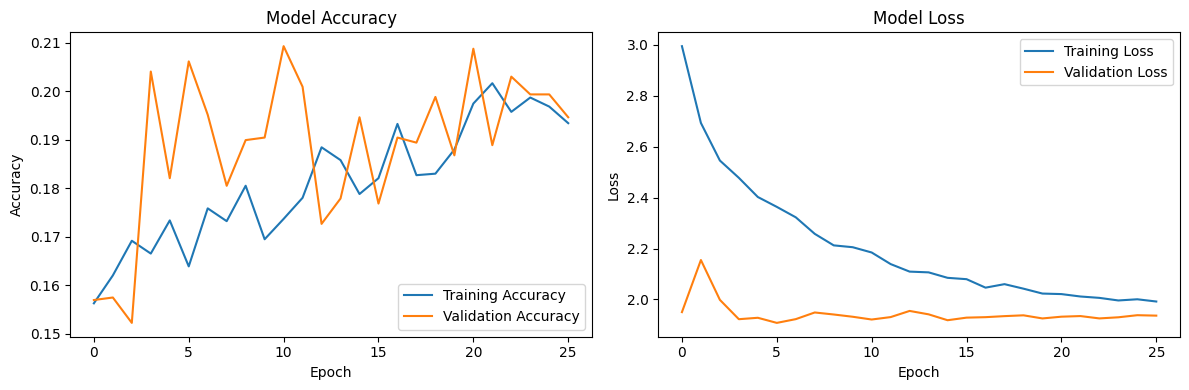

✅ Training completed!


True

In [11]:
setup_and_train()

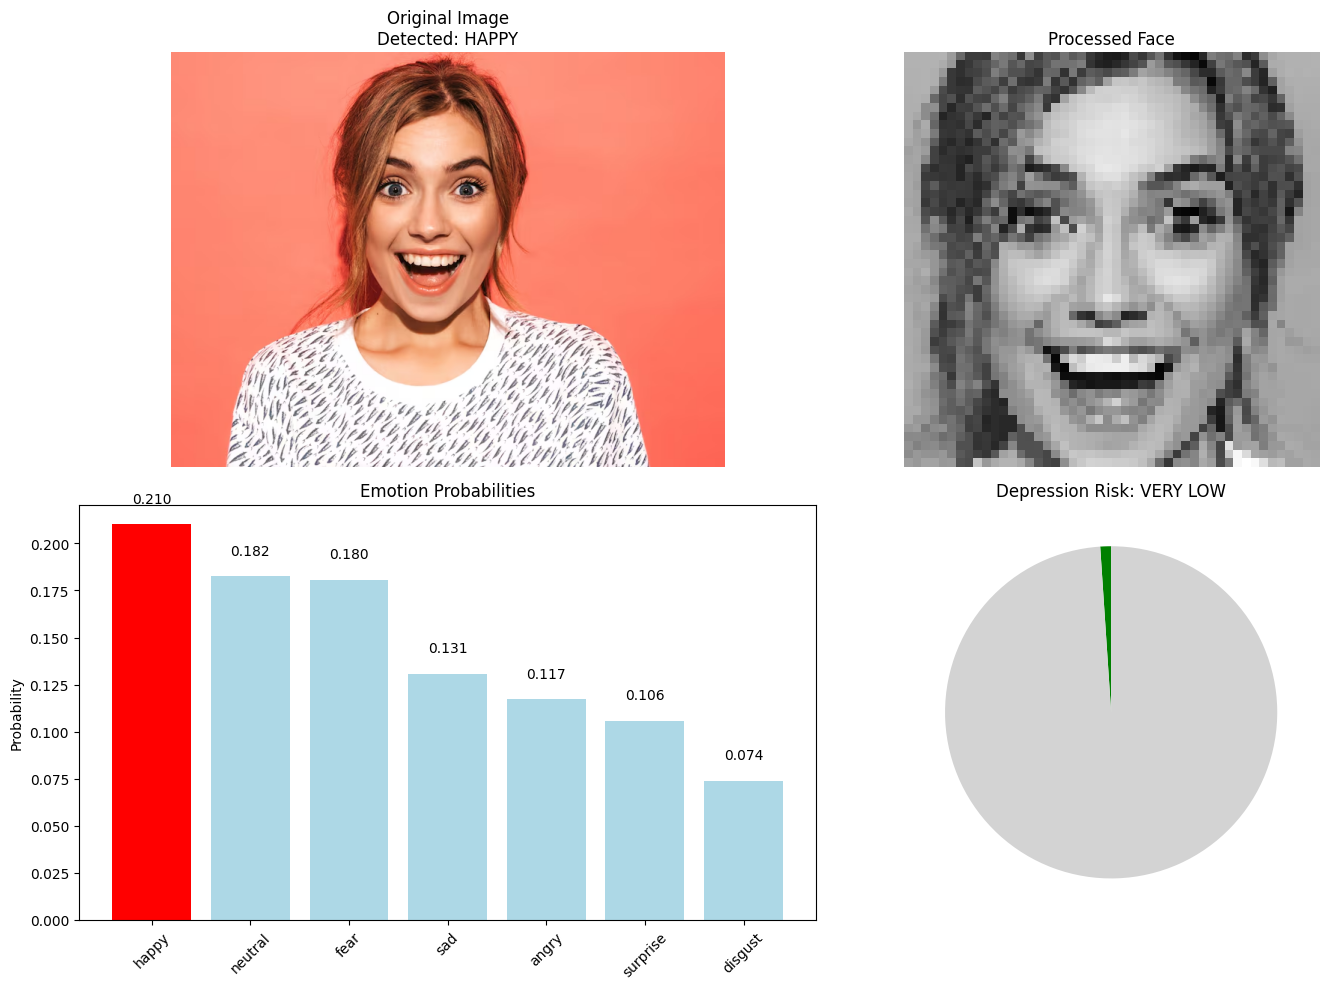


🧠 EMOTION ANALYSIS RESULTS
🎯 Primary Emotion: HAPPY
📊 Confidence: 0.2100
🧠 Depression Status: NO DEPRESSION INDICATORS
⚠️  Risk Level: VERY LOW
📈 Depression Score: 0.0105
📝 Description: Positive emotions indicate good mental health

📊 All Emotion Probabilities:
   Happy: 0.2100
   Neutral: 0.1824
   Fear: 0.1805
   Sad: 0.1306
   Angry: 0.1171
   Surprise: 0.1056
   Disgust: 0.0738


{'primary_emotion': np.str_('happy'),
 'confidence': np.float32(0.21004695),
 'all_emotions': {np.str_('happy'): np.float32(0.21004695),
  np.str_('neutral'): np.float32(0.18244232),
  np.str_('fear'): np.float32(0.18046488),
  np.str_('sad'): np.float32(0.13055237),
  np.str_('angry'): np.float32(0.11714246),
  np.str_('surprise'): np.float32(0.10559827),
  np.str_('disgust'): np.float32(0.07375273)},
 'depression_score': np.float32(0.010502348),
 'depression_status': 'NO DEPRESSION INDICATORS',
 'risk_level': 'VERY LOW',
 'description': 'Positive emotions indicate good mental health'}

In [13]:
analyze_image('/content/happy.avif')

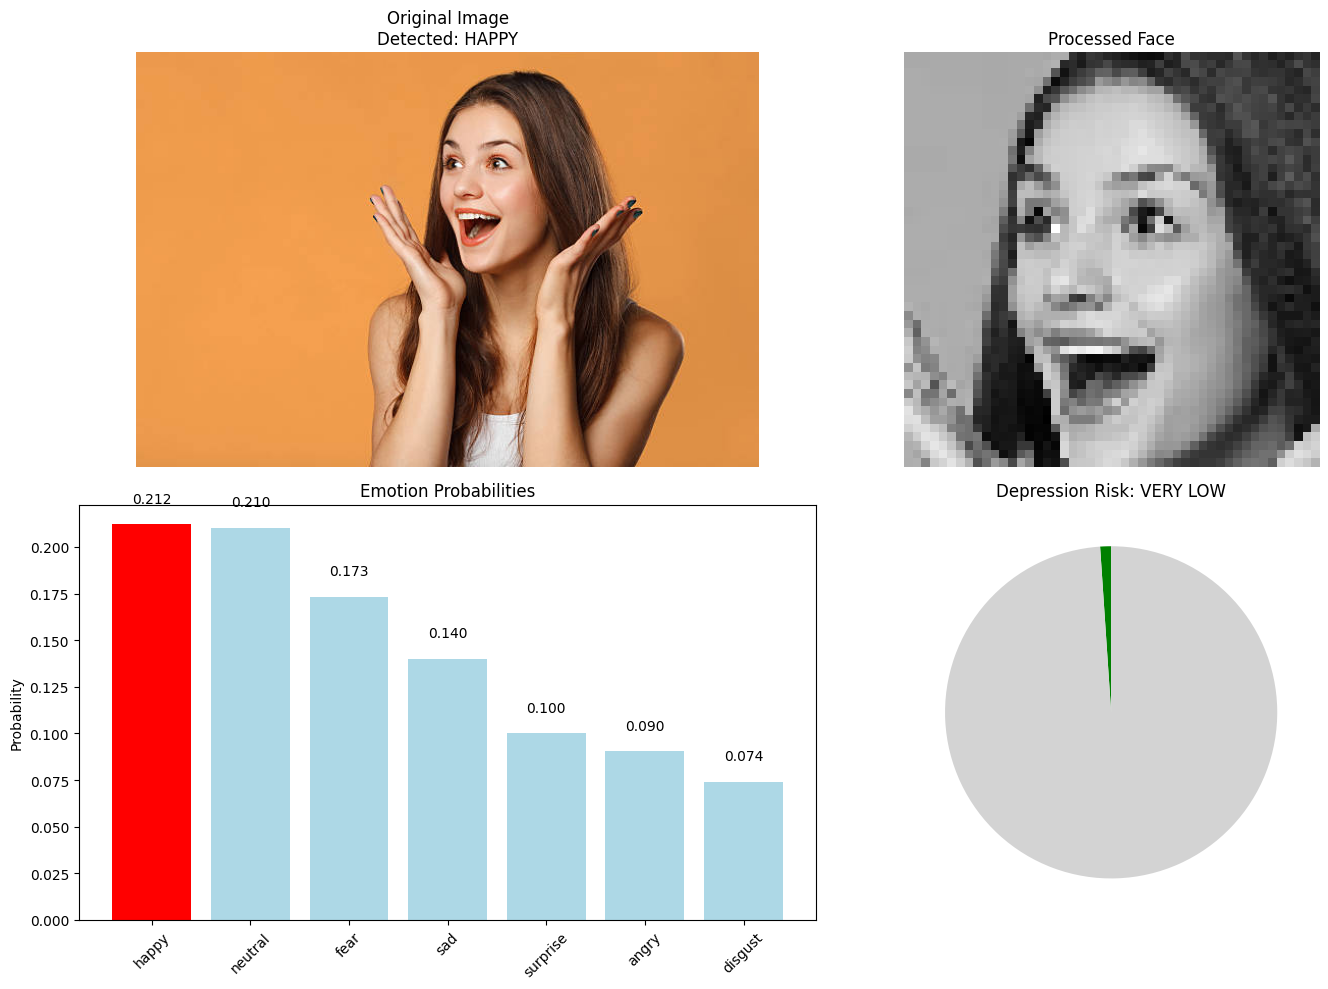


🧠 EMOTION ANALYSIS RESULTS
🎯 Primary Emotion: HAPPY
📊 Confidence: 0.2120
🧠 Depression Status: NO DEPRESSION INDICATORS
⚠️  Risk Level: VERY LOW
📈 Depression Score: 0.0106
📝 Description: Positive emotions indicate good mental health

📊 All Emotion Probabilities:
   Happy: 0.2120
   Neutral: 0.2102
   Fear: 0.1732
   Sad: 0.1401
   Surprise: 0.1001
   Angry: 0.0903
   Disgust: 0.0740


{'primary_emotion': np.str_('happy'),
 'confidence': np.float32(0.21201624),
 'all_emotions': {np.str_('happy'): np.float32(0.21201624),
  np.str_('neutral'): np.float32(0.21020831),
  np.str_('fear'): np.float32(0.17322932),
  np.str_('sad'): np.float32(0.1401215),
  np.str_('surprise'): np.float32(0.10005437),
  np.str_('angry'): np.float32(0.09033071),
  np.str_('disgust'): np.float32(0.07403946)},
 'depression_score': np.float32(0.010600812),
 'depression_status': 'NO DEPRESSION INDICATORS',
 'risk_level': 'VERY LOW',
 'description': 'Positive emotions indicate good mental health'}

In [15]:
analyze_image('/content/surprisegirl.jpg')

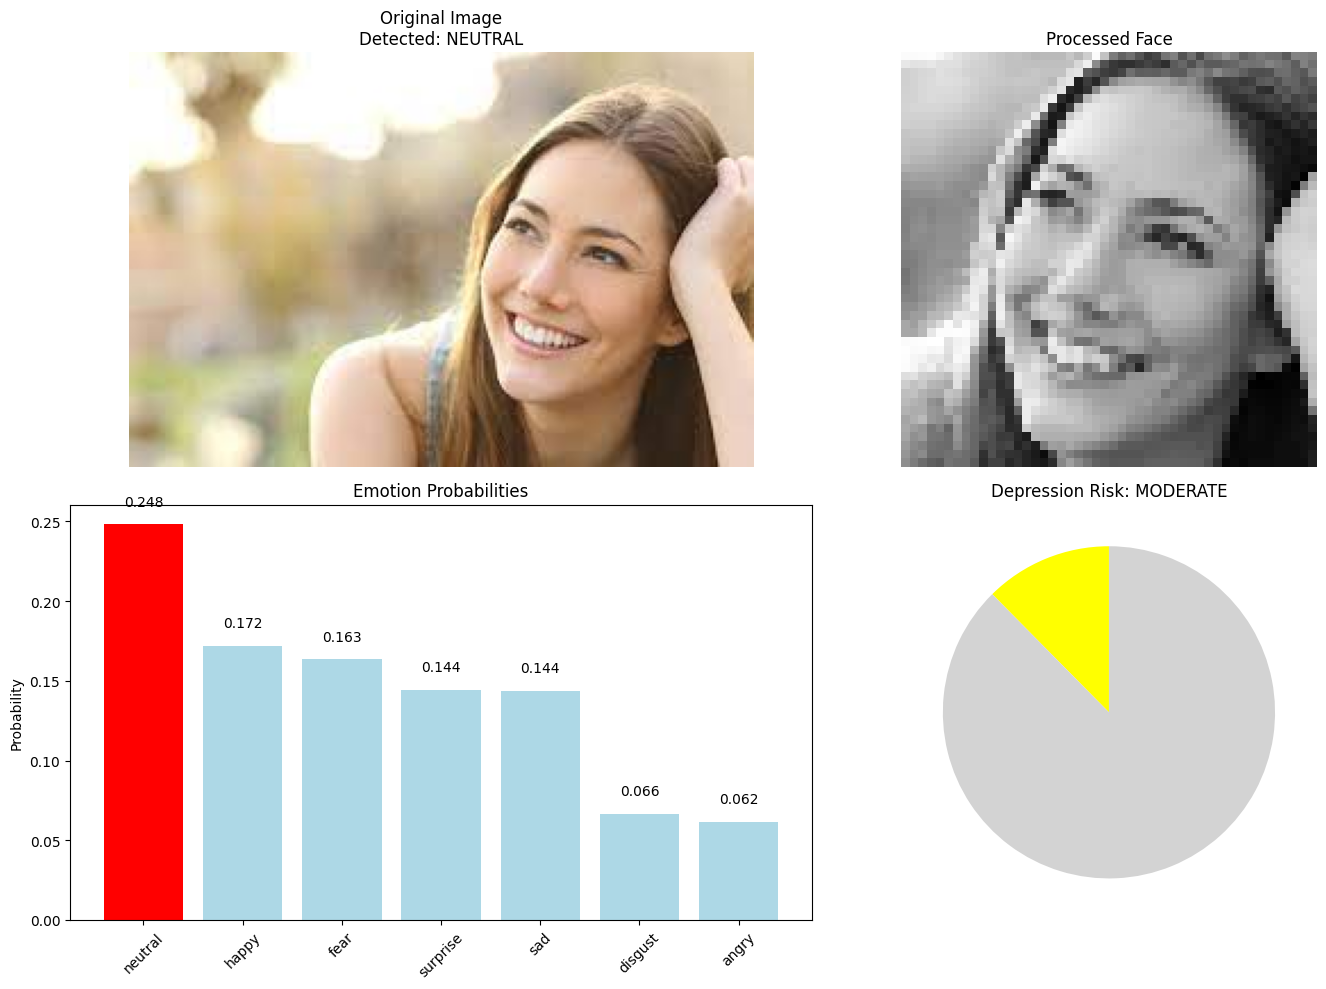


🧠 EMOTION ANALYSIS RESULTS
🎯 Primary Emotion: NEUTRAL
📊 Confidence: 0.2481
🧠 Depression Status: MILD DEPRESSION INDICATORS
⚠️  Risk Level: MODERATE
📈 Depression Score: 0.1240
📝 Description: Flat affect may indicate emotional numbness

📊 All Emotion Probabilities:
   Neutral: 0.2481
   Happy: 0.1721
   Fear: 0.1634
   Surprise: 0.1443
   Sad: 0.1439
   Disgust: 0.0664
   Angry: 0.0617


{'primary_emotion': np.str_('neutral'),
 'confidence': np.float32(0.24808899),
 'all_emotions': {np.str_('neutral'): np.float32(0.24808899),
  np.str_('happy'): np.float32(0.17213619),
  np.str_('fear'): np.float32(0.16341539),
  np.str_('surprise'): np.float32(0.14434534),
  np.str_('sad'): np.float32(0.14388448),
  np.str_('disgust'): np.float32(0.06642635),
  np.str_('angry'): np.float32(0.061703306)},
 'depression_score': np.float32(0.12404449),
 'depression_status': 'MILD DEPRESSION INDICATORS',
 'risk_level': 'MODERATE',
 'description': 'Flat affect may indicate emotional numbness'}

In [16]:
analyze_image('/content/happy1.jpg')

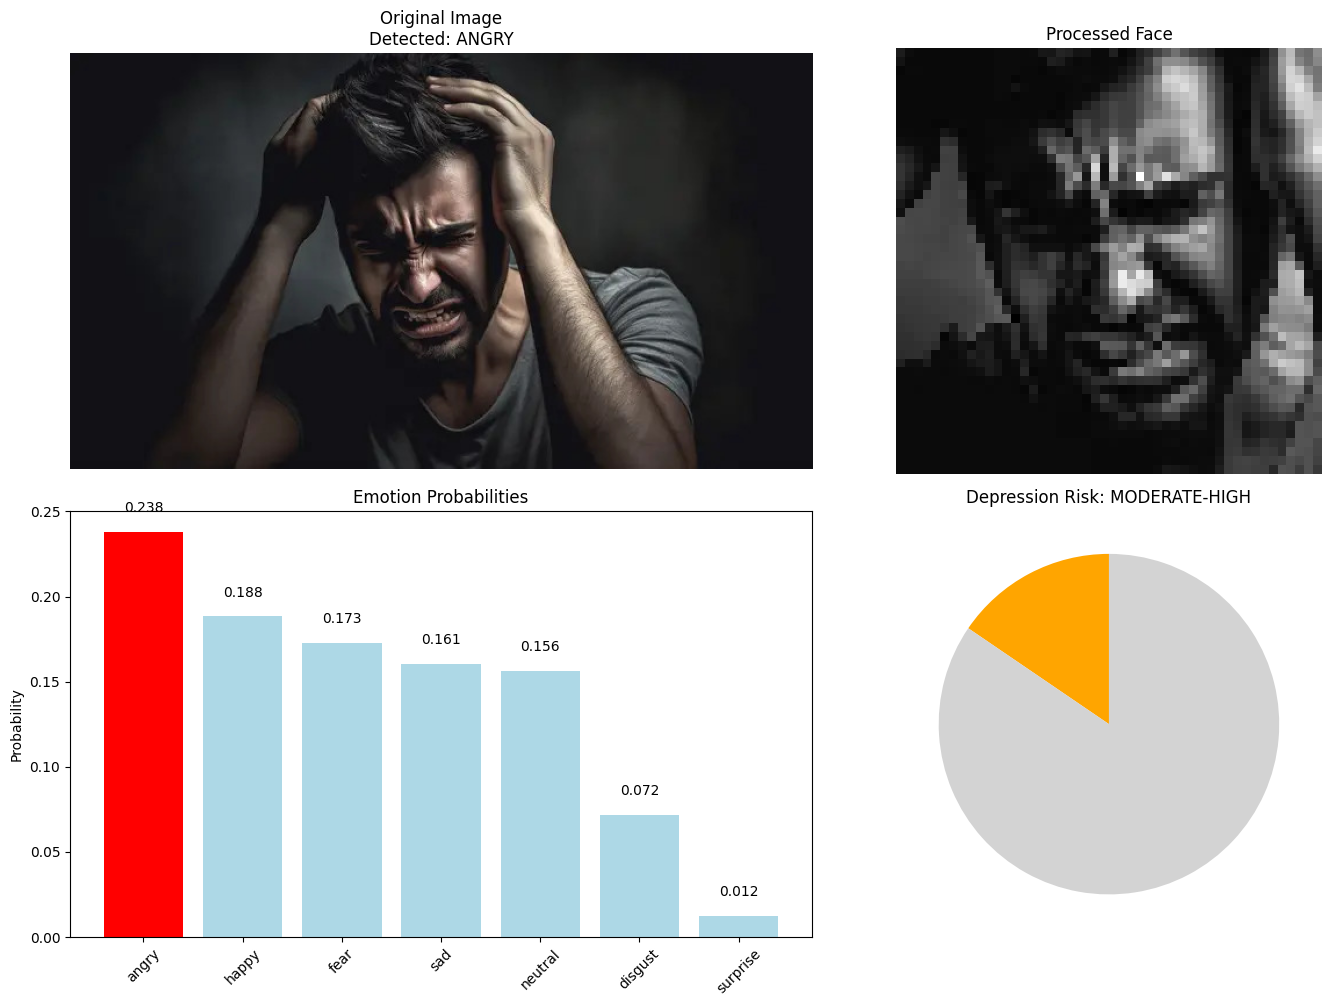


🧠 EMOTION ANALYSIS RESULTS
🎯 Primary Emotion: ANGRY
📊 Confidence: 0.2381
🧠 Depression Status: DEPRESSION POSSIBLE
⚠️  Risk Level: MODERATE-HIGH
📈 Depression Score: 0.1548
📝 Description: Irritability can be a depression symptom

📊 All Emotion Probabilities:
   Angry: 0.2381
   Happy: 0.1883
   Fear: 0.1729
   Sad: 0.1606
   Neutral: 0.1562
   Disgust: 0.0715
   Surprise: 0.0123


{'primary_emotion': np.str_('angry'),
 'confidence': np.float32(0.23814943),
 'all_emotions': {np.str_('angry'): np.float32(0.23814943),
  np.str_('happy'): np.float32(0.1882999),
  np.str_('fear'): np.float32(0.17290363),
  np.str_('sad'): np.float32(0.16064218),
  np.str_('neutral'): np.float32(0.15615779),
  np.str_('disgust'): np.float32(0.0715303),
  np.str_('surprise'): np.float32(0.012316807)},
 'depression_score': np.float32(0.15479712),
 'depression_status': 'DEPRESSION POSSIBLE',
 'risk_level': 'MODERATE-HIGH',
 'description': 'Irritability can be a depression symptom'}

In [17]:
analyze_image('/content/sad4.jpg')

📸 Starting Real-time Emotion Detection!
Click 'Capture' to analyze your emotion


<IPython.core.display.Javascript object>

🔍 Analyzing captured image...


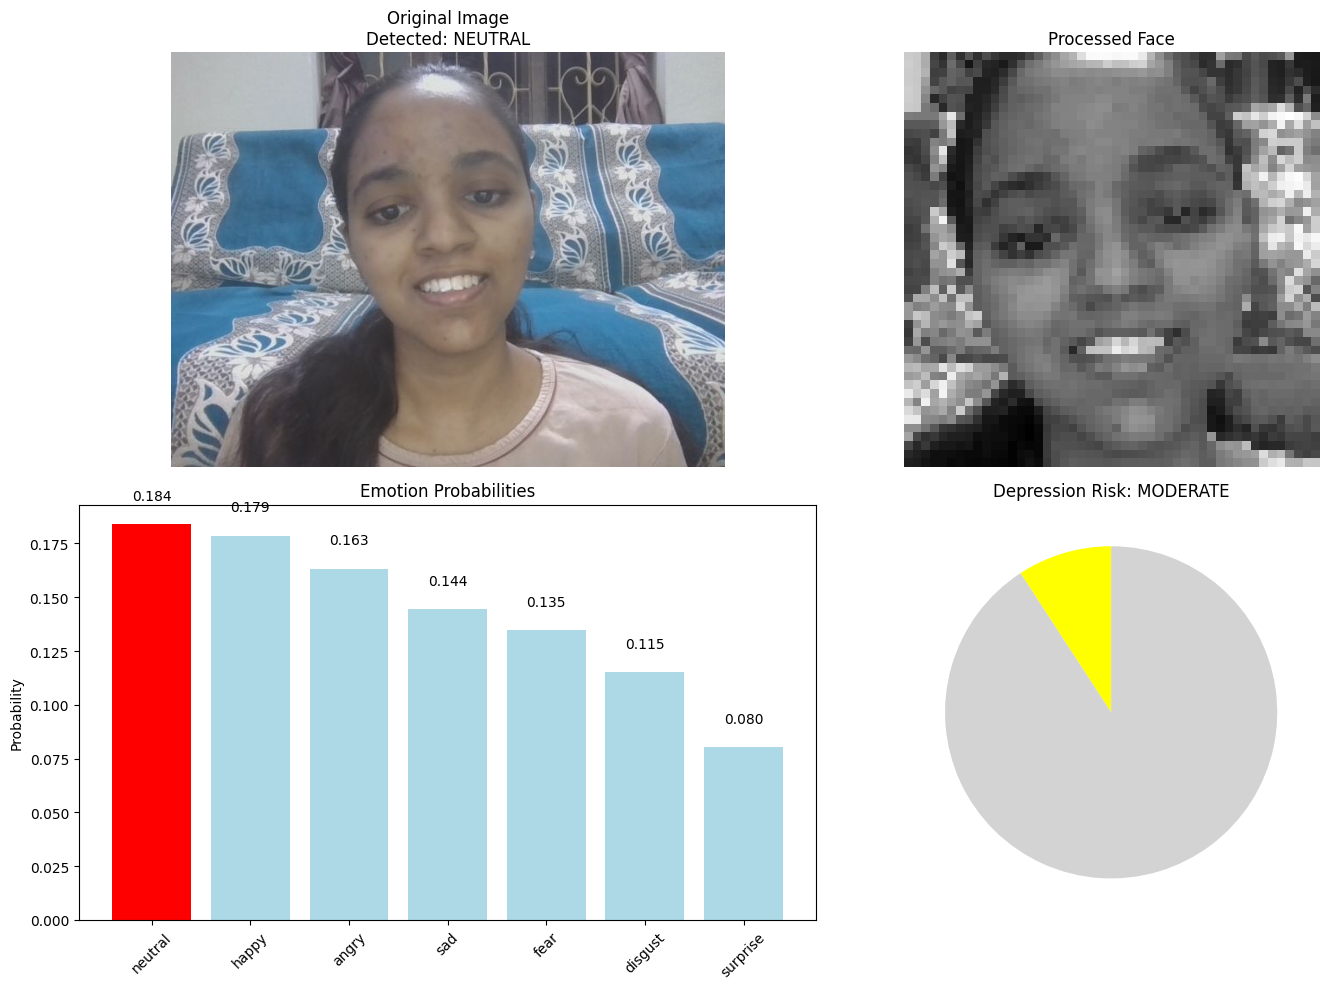


🧠 EMOTION ANALYSIS RESULTS
🎯 Primary Emotion: NEUTRAL
📊 Confidence: 0.1838
🧠 Depression Status: MILD DEPRESSION INDICATORS
⚠️  Risk Level: MODERATE
📈 Depression Score: 0.0919
📝 Description: Flat affect may indicate emotional numbness

📊 All Emotion Probabilities:
   Neutral: 0.1838
   Happy: 0.1785
   Angry: 0.1631
   Sad: 0.1444
   Fear: 0.1346
   Disgust: 0.1152
   Surprise: 0.0803
✅ Analysis complete!


In [21]:
start_camera()

📁 Please upload an image file:


Saving Screenshot 2026-01-13 210405.png to Screenshot 2026-01-13 210405.png
🔍 Analyzing Screenshot 2026-01-13 210405.png...


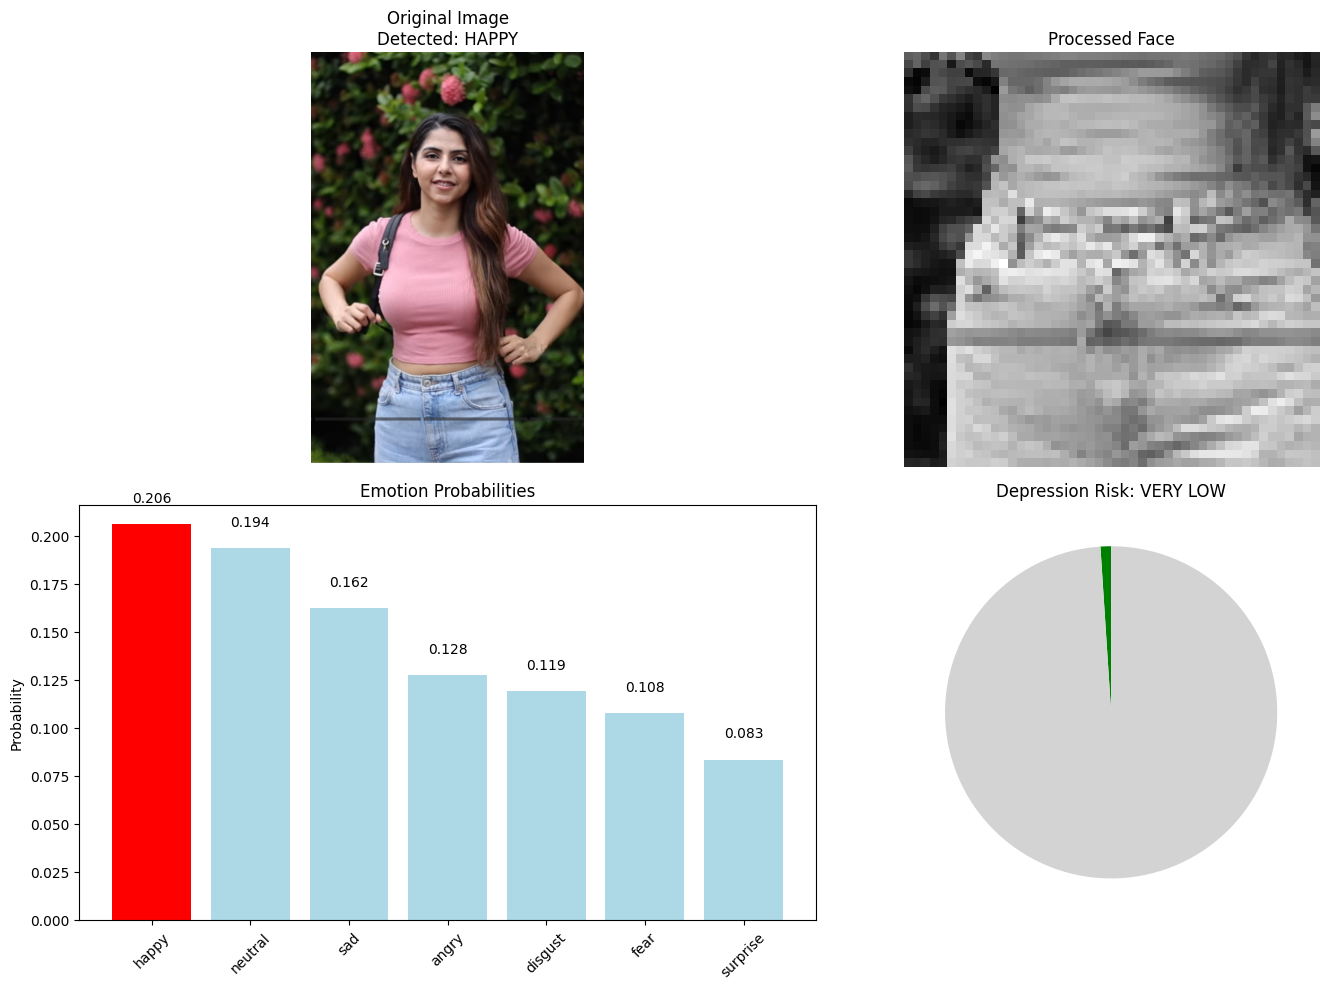


🧠 EMOTION ANALYSIS RESULTS
🎯 Primary Emotion: HAPPY
📊 Confidence: 0.2059
🧠 Depression Status: NO DEPRESSION INDICATORS
⚠️  Risk Level: VERY LOW
📈 Depression Score: 0.0103
📝 Description: Positive emotions indicate good mental health

📊 All Emotion Probabilities:
   Happy: 0.2059
   Neutral: 0.1936
   Sad: 0.1624
   Angry: 0.1276
   Disgust: 0.1193
   Fear: 0.1078
   Surprise: 0.0835


In [30]:
upload_and_analyze()